In [27]:
%load_ext autoreload
%autoreload 2
import sys
from freq2clean import Freq2Clean
import torch

sys.path.append("..")
from src import *

Cupy Available= 1


In [16]:
trainings = sorted(Path("trainings").glob("*/"), reverse=True)
cprint(*[f"rand:{training.stem}" for training in trainings], sep='\n')

20251121-1418-synthetic_deepcad_15
20251120-1440-mouse_neuronal_populations_deepcad_15
20251120-1434-mouse_neuronal_populations_deepcad_15
20251120-1428-mouse_neuronal_populations_deepcad_15
20251120-1237-mouse_neuronal_populations_deepcad_15
20251118-1221-synthetic_deepcad_150
20251118-1205-synthetic_deepcad_15
20251112-1153-synthetic_deepcad_150
20251112-1054-synthetic_deepcad_150
20251112-1044-synthetic_deepcad_150
20251112-1038-synthetic_deepcad_150
20251112-1034-synthetic_deepcad_150


In [5]:
SELECTED_TRAINING = "20251121-1418-synthetic_deepcad_15"

In [19]:
training_dir = Path("trainings") / SELECTED_TRAINING
cfg = json.load(open(training_dir / "cfg.json"))
ckpts = sorted((training_dir / "pth").glob("*.pt"), key=lambda file: int(file.stem))
cprint(*[f"rand:{ckpt.stem}{ckpt.suffix}" for ckpt in ckpts], sep='\t')

0.pt	1.pt	2.pt	3.pt	4.pt	5.pt	6.pt	7.pt	8.pt	9.pt	10.pt	11.pt	12.pt	13.pt	14.pt	15.pt	16.pt	17.pt	18.pt	19.pt


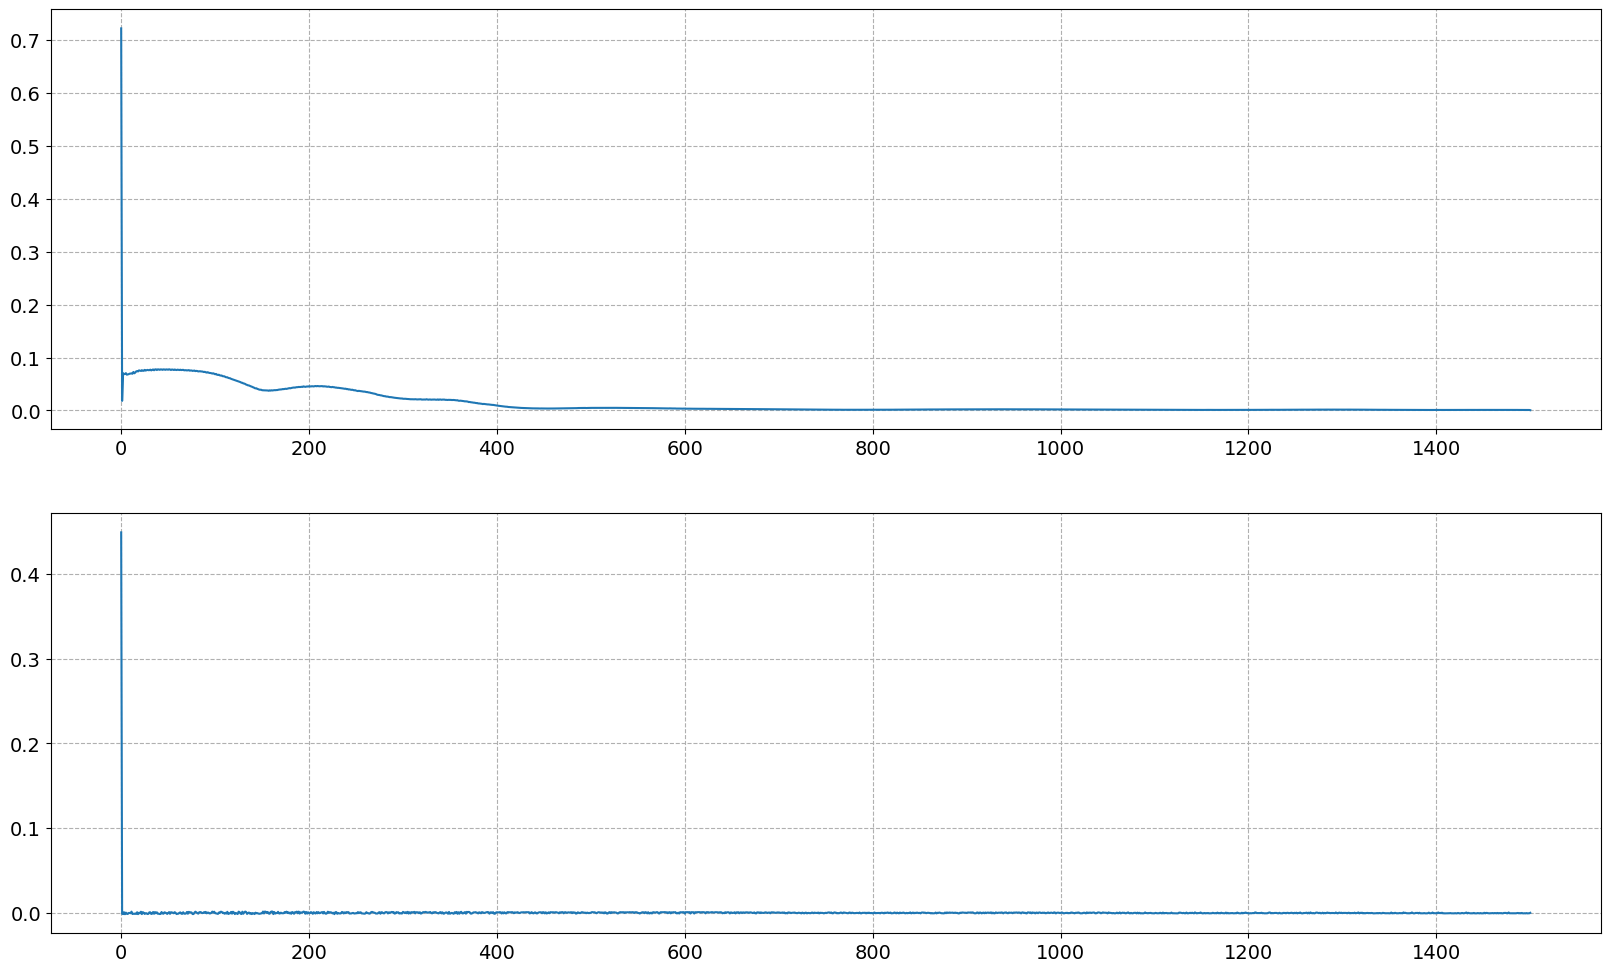

In [30]:
SELECTED_CKPT = 19
model = Freq2Clean(num_frames=cfg["patch_t"], train_phase=cfg["train_phase"])
model.load_state_dict(torch.load(training_dir / f"pth/{SELECTED_CKPT}.pt"))

fig, axs = plt.subplots(2,1,figsize=(20, 12))
pd.Series(model.alphas.cpu().detach().numpy()).plot(ax=axs[0])
pd.Series(model.betas.cpu().detach().numpy()).plot(ax=axs[1])
plt.show()